# Lahore Methane Column (TROPOMI / Sentinel-5P)
## Export: 250 m point GeoJSON + GeoTIFF for use in the HUDI index

**Source:** ESA Sentinel-5P TROPOMI `COPERNICUS/S5P/OFFL/L3_CH4`  
**Band:** `CH4_column_volume_mixing_ratio_dry_air` (ppb)  
**Native resolution:** ~5.5 km × 7 km per pixel  
**Output resolution:** 250 m (resampled from native via GEE; spatial detail reflects ~5.5 km source)  

**Interpretation:** Higher CH4 column mixing ratio = more methane overhead = worse air quality.  
Direction for HUDI EQ index: `lower_better`.

**Lahore methane sources:** gas distribution network leaks, landfills (Mahmood Booti, Lakhodair),  
industrial combustion, agricultural fields at the urban fringe.

### 0. Initialize Earth Engine

In [1]:
import calendar
import urllib.request

import ee
import geemap
import geopandas as gpd

EE_PROJECT = "1035330553052"
try:
    ee.Initialize(project=EE_PROJECT)
except Exception:
    ee.Authenticate(auth_mode="localhost")
    ee.Initialize(project=EE_PROJECT)

/Users/ahmed/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### 1. Parameters

In [2]:
UC_SHP    = "../../data/Lahore UCs/Lahore UC.shp"
YEAR      = 2026
MONTH     = 2

# Earth Engine's CH4 L3 ingestion is already derived from L2 validity > 50.
# No qa_value band is exposed in the EE CH4 asset, so we do not apply a second QA mask here.
USE_BIAS_CORRECTED = True

# Output scale in metres.  TROPOMI native ~5500 m; 250 m matches the HUDI grid.
EXPORT_SCALE_M = 250

last_day   = calendar.monthrange(YEAR, MONTH)[1]
START      = f"{YEAR:04d}-{MONTH:02d}-01"
END        = f"{YEAR:04d}-{MONTH:02d}-{last_day:02d}"
OUT_PREFIX = f"CH4_Lahore_{calendar.month_abbr[MONTH]}{YEAR}"

print(f"Date range : {START} → {END}")
print("Filtering  : EE L3 CH4 already ingested from L2 with validity > 50")
print(f"Output     : {OUT_PREFIX}_points_{EXPORT_SCALE_M}m.geojson")

Date range : 2026-02-01 → 2026-02-28
Filtering  : EE L3 CH4 already ingested from L2 with validity > 50
Output     : CH4_Lahore_Feb2026_points_250m.geojson


### 2. Load Lahore Boundary

In [3]:
gdf = gpd.read_file(UC_SHP)
if gdf.crs is None or gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs(4326)
gdf["geometry"] = gdf["geometry"].buffer(0)

ucs_fc = geemap.gdf_to_ee(gdf)
region = ucs_fc.geometry()

print(f"Lahore boundary loaded: {len(gdf)} union council polygons")
print(f"Bounds: {gdf.total_bounds.round(4)}")

Lahore boundary loaded: 171 union council polygons
Bounds: [74.0033 31.2503 74.6421 31.7386]


### 3. Build Monthly TROPOMI CH4 Composite

Each S5P L3 granule is already a daily gridded product at ~0.05° (~5.5 km).  
For the Earth Engine CH4 L3 asset, the original L2 validity threshold has already been applied during ingestion,
and the `qa_value` band is not exposed on the final EE image.  
So we use the available CH4 band directly and take the monthly median to reduce transient retrieval noise.

In [4]:
CH4_COLLECTION = "COPERNICUS/S5P/OFFL/L3_CH4"
RAW_BAND       = "CH4_column_volume_mixing_ratio_dry_air"  # unit: ppb
BIAS_BAND      = "CH4_column_volume_mixing_ratio_dry_air_bias_corrected"
UNC_BAND       = "CH4_column_volume_mixing_ratio_dry_air_uncertainty"

collection_raw = (
    ee.ImageCollection(CH4_COLLECTION)
    .filterBounds(region)
    .filterDate(START, END)
)

count = collection_raw.size().getInfo()
print(f"Granules available: {count}")

if count == 0:
    raise RuntimeError(
        f"No S5P CH4 granules found for {START}–{END} over Lahore. "
        "Try a different month or check your EE authentication."
    )

available_bands = ee.Image(collection_raw.first()).bandNames().getInfo()
band_to_use = BIAS_BAND if USE_BIAS_CORRECTED and BIAS_BAND in available_bands else RAW_BAND
print(f"Using band  : {band_to_use}")

collection = collection_raw.select([band_to_use])

# Monthly median composite (robust to single-day retrieval noise)
ch4_med = collection.median().rename("CH4_ppb").clip(region)

# Quick sanity check: sample a few pixel values
sample_val = ch4_med.reduceRegion(
    reducer=ee.Reducer.percentile([5, 50, 95]),
    geometry=region,
    scale=5500,
    maxPixels=1e6,
).getInfo()
print(f"CH4 column [ppb]  p5={sample_val.get('CH4_ppb_p5'):.1f}  "
      f"median={sample_val.get('CH4_ppb_p50'):.1f}  "
      f"p95={sample_val.get('CH4_ppb_p95'):.1f}")
print("Typical global background: ~1850–1950 ppb. Hotspots often >1970 ppb.")

Granules available: 380
Using band  : CH4_column_volume_mixing_ratio_dry_air_bias_corrected
CH4 column [ppb]  p5=1946.7  median=1962.3  p95=1981.4
Typical global background: ~1850–1950 ppb. Hotspots often >1970 ppb.


### 4. Export GeoTIFF (at native TROPOMI scale) and 250 m Point GeoJSON

In [5]:
# ── GeoTIFF at native TROPOMI resolution (~5500 m) ────────────────────────────
tif_path = f"{OUT_PREFIX}_5500m.tif"

def export_image_local(img, filename, region, scale=5500, crs="EPSG:4326"):
    try:
        geemap.ee_export_image(
            img.clip(region), filename, scale=scale, region=region, file_per_band=False
        )
        print(f"[OK] GeoTIFF → {filename}")
        return
    except Exception as e:
        print(f"[INFO] ee_export_image: {e}")

    try:
        geemap.download_ee_image(
            img.clip(region), filename=filename, scale=scale, region=region, crs=crs
        )
        print(f"[OK] GeoTIFF (download_ee_image) → {filename}")
        return
    except Exception as e:
        print(f"[INFO] download_ee_image: {e}")

    url = img.clip(region).getDownloadURL(
        {"scale": scale, "crs": crs, "region": region, "filePerBand": False}
    )
    urllib.request.urlretrieve(url, filename)
    print(f"[OK] GeoTIFF (getDownloadURL) → {filename}")


export_image_local(ch4_med, tif_path, region, scale=5500)

Generating URL ...
Please wait ...
Data downloaded to /Users/ahmed/Desktop/Senior Spring 26/SPROJ - Dr Tahir/SPROJ/notebooks/methane/CH4_Lahore_Feb2026_5500m.tif
[OK] GeoTIFF → CH4_Lahore_Feb2026_5500m.tif


In [6]:
# ── 250 m point GeoJSON (for HUDI index grid join) ────────────────────────────
# GEE resamples the ~5500 m TROPOMI pixel to 250 m via nearest-neighbour.
# The spatial resolution is still ~5.5 km; the dense point grid just makes
# joining onto the HUDI 250 m grid straightforward.

pts_fc = (
    ee.Image.pixelLonLat()
    .addBands(ch4_med.rename("val"))
    .sample(
        region=region,
        scale=EXPORT_SCALE_M,
        geometries=True,
        seed=1,
    )
)

geojson_path = f"{OUT_PREFIX}_points_{EXPORT_SCALE_M}m.geojson"
geemap.ee_export_vector(pts_fc, filename=geojson_path)
print(f"[OK] GeoJSON points → {geojson_path}")

Generating URL ...
Please wait ...
Data downloaded to /Users/ahmed/Desktop/Senior Spring 26/SPROJ - Dr Tahir/SPROJ/notebooks/methane/CH4_Lahore_Feb2026_points_250m.geojson
[OK] GeoJSON points → CH4_Lahore_Feb2026_points_250m.geojson


### 5. Quick Verification Map

Points exported : 33,678
CH4 range       : 1939.7 – 1988.1 ppb
Median          : 1962.6 ppb


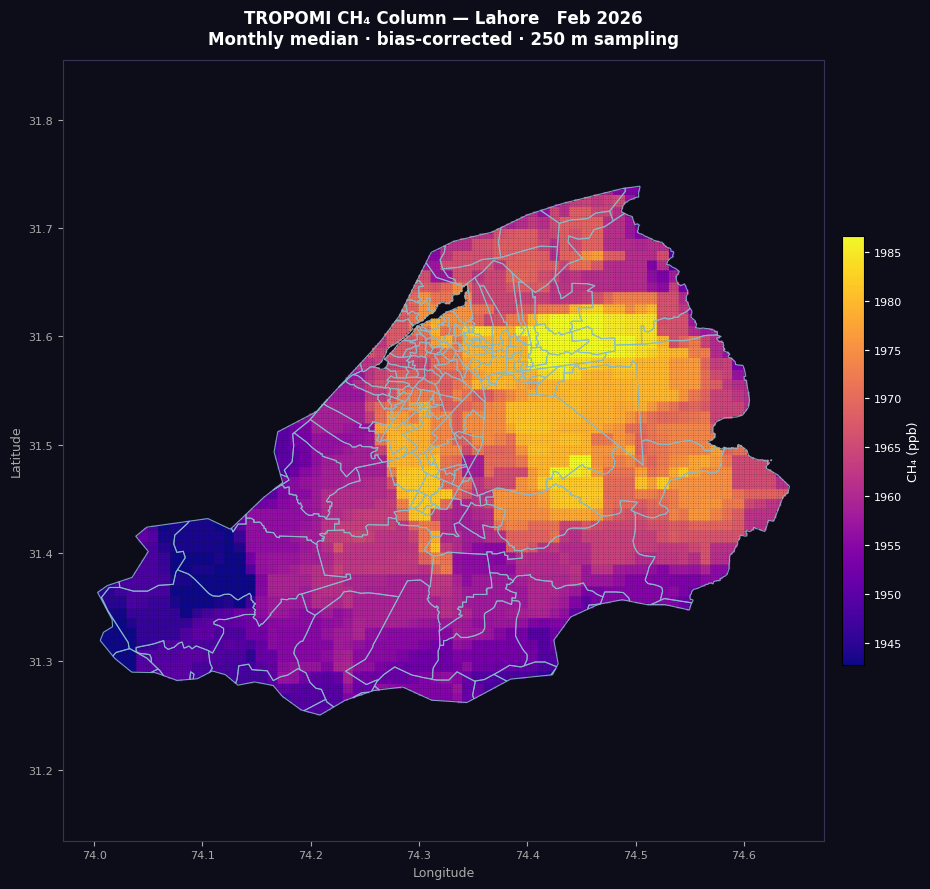

[OK] Map saved → CH4_Lahore_Feb2026_map.png


In [7]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

gdf_pts = gpd.read_file(geojson_path)
gdf_pts = gdf_pts[gdf_pts["val"].notna()]

print(f"Points exported : {len(gdf_pts):,}")
print(f"CH4 range       : {gdf_pts['val'].min():.1f} – {gdf_pts['val'].max():.1f} ppb")
print(f"Median          : {gdf_pts['val'].median():.1f} ppb")

vmin = gdf_pts["val"].quantile(0.02)
vmax = gdf_pts["val"].quantile(0.98)

fig, ax = plt.subplots(figsize=(10, 9), facecolor="#0d0d1a")
ax.set_facecolor("#0d0d1a")

# Plasma colormap — standard in atmospheric methane papers (deep purple → bright yellow)
gdf_pts.plot(
    column="val",
    cmap="plasma",
    markersize=1.5,
    legend=True,
    legend_kwds={
        "label": "CH₄ column mixing ratio (ppb)",
        "shrink": 0.55,
        "pad": 0.02,
    },
    ax=ax,
    vmin=vmin,
    vmax=vmax,
)

# Style colorbar
cbar = fig.axes[-1]
cbar.tick_params(colors="white", labelsize=8)
cbar.set_ylabel("CH₄ (ppb)", color="white", fontsize=9)
cbar.yaxis.label.set_color("white")

# Boundary outline
gdf.boundary.plot(ax=ax, color="#88bbcc", linewidth=0.8, alpha=0.85)

ax.set_title(
    f"TROPOMI CH₄ Column — Lahore   {calendar.month_abbr[MONTH]} {YEAR}\n"
    f"Monthly median · bias-corrected · {EXPORT_SCALE_M} m sampling",
    fontsize=12, color="white", pad=12, fontweight="bold",
)
ax.set_xlabel("Longitude", color="#aaaaaa", fontsize=9)
ax.set_ylabel("Latitude",  color="#aaaaaa", fontsize=9)
ax.tick_params(colors="#aaaaaa", labelsize=8)
for spine in ax.spines.values():
    spine.set_edgecolor("#333355")
ax.axis("equal")

plt.tight_layout()
plt.savefig(f"{OUT_PREFIX}_map.png", dpi=180, facecolor="#0d0d1a", bbox_inches="tight")
plt.show()
print(f"[OK] Map saved → {OUT_PREFIX}_map.png")

### 6. Summary Statistics and HUDI Index Notes

| Property | Value |
|---|---|
| Unit | ppb (parts per billion by volume, dry air) |
| Typical background | 1850–1950 ppb globally |
| Direction (HUDI) | **lower_better** — higher CH4 = worse air quality |
| Index sub-component | EQ (Environmental Quality) |
| Suggested column name | `ch4` |
| Spatial caveat | Native TROPOMI resolution ~5.5 km; spatial pattern reflects city-scale variation, not block-level |

**Next step:** Add this layer to `notebooks/index.ipynb` in the spatial join section,
joining on nearest centroid at 250 m, then include `ch4` as an EQ metric with `lower_better` direction.

In [8]:
import numpy as np

vals = gdf_pts["val"].dropna().values
quantiles = np.percentile(vals, [2, 5, 25, 50, 75, 95, 98])

print("=" * 45)
print(f"  TROPOMI CH4 — {OUT_PREFIX}")
print("=" * 45)
print(f"  N points     : {len(vals):,}")
print(f"  Min          : {vals.min():.2f} ppb")
print(f"  p02          : {quantiles[0]:.2f} ppb  ← robust lo")
print(f"  p05          : {quantiles[1]:.2f} ppb")
print(f"  p25          : {quantiles[2]:.2f} ppb")
print(f"  Median       : {quantiles[3]:.2f} ppb")
print(f"  p75          : {quantiles[4]:.2f} ppb")
print(f"  p95          : {quantiles[5]:.2f} ppb")
print(f"  p98          : {quantiles[6]:.2f} ppb  ← robust hi")
print(f"  Max          : {vals.max():.2f} ppb")
print("=" * 45)
print()
print("Add to manifest.json metrics:")
print("{")
print('  "key": "ch4",')
print('  "label": "Methane (CH4)",')
print('  "column": "ch4",')
print('  "direction": "lower_better",')
print('  "default_weight": 0.5,')
print('  "available": true,')
print(f'  "min": {vals.min():.2f},')
print(f'  "max": {vals.max():.2f},')
print(f'  "q05": {quantiles[1]:.2f},')
print(f'  "q95": {quantiles[5]:.2f}')
print("}")

  TROPOMI CH4 — CH4_Lahore_Feb2026
  N points     : 33,678
  Min          : 1939.72 ppb
  p02          : 1942.69 ppb  ← robust lo
  p05          : 1945.87 ppb
  p25          : 1956.20 ppb
  Median       : 1962.65 ppb
  p75          : 1972.84 ppb
  p95          : 1981.91 ppb
  p98          : 1986.64 ppb  ← robust hi
  Max          : 1988.14 ppb

Add to manifest.json metrics:
{
  "key": "ch4",
  "label": "Methane (CH4)",
  "column": "ch4",
  "direction": "lower_better",
  "default_weight": 0.5,
  "available": true,
  "min": 1939.72,
  "max": 1988.14,
  "q05": 1945.87,
  "q95": 1981.91
}


### 7. (Optional) Export to Google Drive for Large Area Coverage

If the local download above fails due to size or timeout, use this cell to submit a Drive export task.

In [9]:
# ── Drive export (run only if local download failed) ──────────────────────────
RUN_DRIVE_EXPORT = False  # Set to True to submit

if RUN_DRIVE_EXPORT:
    pts_fc_drive = (
        ee.Image.pixelLonLat()
        .addBands(ch4_med.rename("val"))
        .sample(region=region, scale=EXPORT_SCALE_M, geometries=True, seed=1)
    )

    task = ee.batch.Export.table.toDrive(
        collection=pts_fc_drive,
        description=f"{OUT_PREFIX}_points_{EXPORT_SCALE_M}m",
        folder="EE_Exports",
        fileNamePrefix=f"{OUT_PREFIX}_points_{EXPORT_SCALE_M}m",
        fileFormat="GeoJSON",
    )
    task.start()
    print(f"Drive export submitted: EE_Exports/{OUT_PREFIX}_points_{EXPORT_SCALE_M}m.geojson")
    print("Check progress at https://code.earthengine.google.com/ → Tasks tab")
    print(f"Or run: task.status()")
else:
    print("Drive export skipped (RUN_DRIVE_EXPORT=False).")

Drive export skipped (RUN_DRIVE_EXPORT=False).
